In [66]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [67]:
relative_benign_path= "data\\processed\\Modbus Dataset\\benign\\ied1a\\MODBUS_ONLY_veth4edc015-normal-4.csv"
relative_attack_path = "data\\processed\\Modbus Dataset\\attack\\external\\ied1a\\MODBUS_ONLY_veth4edc015-0.csv"  # Example attack file

absolute_benign_path = (Path("../..") / relative_benign_path).resolve()
absolute_external_attack_path = (Path("../..") / relative_attack_path).resolve()

# Print the absolute paths
print("Absolute path to clean data:", absolute_benign_path)
print("Absolute path to external attack data:", absolute_external_attack_path)

Absolute path to clean data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\Modbus Dataset\benign\ied1a\MODBUS_ONLY_veth4edc015-normal-4.csv
Absolute path to external attack data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\Modbus Dataset\attack\external\ied1a\MODBUS_ONLY_veth4edc015-0.csv


In [68]:
benign_data = pd.read_csv(absolute_benign_path)
attack_data = pd.read_csv(absolute_external_attack_path)

attack_data_copy = attack_data.copy()

print(attack_data.columns.tolist())
print(f"Number of columns in attack data: {len(attack_data.columns)}")
display(attack_data.head())
print(f"Length of attack data: {len(attack_data)}")

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'tcp_stream', 'tcp_time_delta', 'tcp_flags', 'tcp_seq', 'tcp_ack', 'tcp_window_size', 'tcp_retransmission', 'tcp_duplicate_ack', 'tcp_lost_segment', 'tcp_out_of_order', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'request_frame', 'response_frame', 'response_time', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'FIN', 'SYN', 'RST', 'PSH', 'ACK', 'URG', 'inter_arrival_time', 'time_from_start', 'requests_per_second', 'round_trip_time', 'label']
Number of columns in attack data: 48


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,tcp_stream,...,SYN,RST,PSH,ACK,URG,inter_arrival_time,time_from_start,requests_per_second,round_trip_time,label
0,5,1675223325,2023-01-31T22:48:45.486440,Modbus/TCP,185.175.0.3,185.175.0.4,53454,502,12,1,...,0,0,1,1,0,NaN,0.000000,1,0.148968,NORMAL
1,15,1675223326,2023-01-31T22:48:45.635408,Modbus/TCP,185.175.0.4,185.175.0.3,502,53454,11,1,...,0,0,1,1,0,0.148968,0.148968,1,0.148968,NORMAL
2,21,1675223326,2023-01-31T22:48:45.656365,Modbus/TCP,185.175.0.3,185.175.0.4,53456,502,12,3,...,0,0,1,1,0,0.020957,0.169925,2,0.005697,NORMAL
3,26,1675223326,2023-01-31T22:48:45.662062,Modbus/TCP,185.175.0.4,185.175.0.3,502,53456,11,3,...,0,0,1,1,0,0.005697,0.175622,2,0.005697,NORMAL
4,32,1675223326,2023-01-31T22:48:45.663325,Modbus/TCP,185.175.0.3,185.175.0.4,53458,502,12,4,...,0,0,1,1,0,0.001263,0.176885,3,0.385779,NORMAL


Length of attack data: 137543


In [69]:
print(attack_data.dtypes)

packet_number            int64
timestamp                int64
datetime                object
protocols               object
src_ip                  object
dst_ip                  object
src_port                 int64
dst_port                 int64
tcp_len                  int64
tcp_stream               int64
tcp_time_delta         float64
tcp_flags               object
tcp_seq                  int64
tcp_ack                  int64
tcp_window_size          int64
tcp_retransmission       int64
tcp_duplicate_ack        int64
tcp_lost_segment         int64
tcp_out_of_order         int64
transaction_id           int64
protocol_id              int64
modbus_length            int64
unit_id                  int64
function_code            int64
reference_num          float64
word_count             float64
bit_count              float64
byte_count             float64
exception_code         float64
request_frame          float64
response_frame         float64
response_time          float64
pkt_len 

label_numeric          1.000000
function_code          0.854000
requests_per_second    0.765569
time_from_start        0.698926
is_request             0.568289
modbus_length          0.534673
tcp_len                0.388441
pkt_len                0.388441
word_count             0.277876
bit_count              0.267288
tcp_seq                0.010161
FIN                    0.002823
tcp_time_delta        -0.012205
inter_arrival_time    -0.226111
tcp_ack               -0.567895
tcp_window_size       -0.568289
is_response           -0.568289
reference_num         -0.949213
tcp_retransmission          NaN
tcp_duplicate_ack           NaN
tcp_lost_segment            NaN
tcp_out_of_order            NaN
protocol_id                 NaN
byte_count                  NaN
exception_code              NaN
response_time               NaN
is_exception                NaN
SYN                         NaN
RST                         NaN
PSH                         NaN
ACK                         NaN
URG     

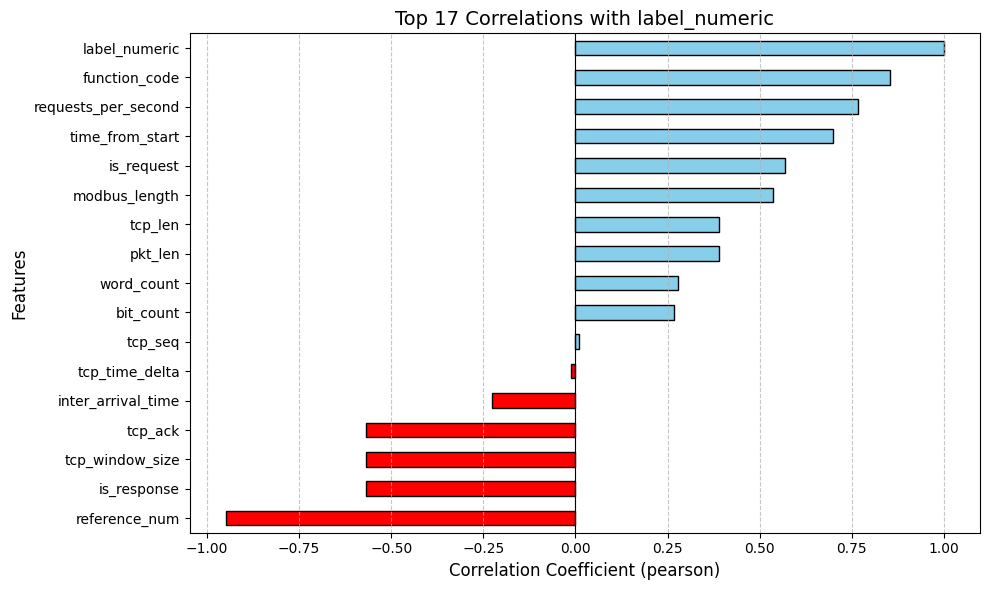

                     label_numeric
label_numeric             1.000000
reference_num            -0.949213
function_code             0.854000
requests_per_second       0.765569
time_from_start           0.698926
is_request                0.568289
is_response              -0.568289
tcp_window_size          -0.568289
tcp_ack                  -0.567895
modbus_length             0.534673
tcp_len                   0.388441
pkt_len                   0.388441
word_count                0.277876
bit_count                 0.267288
inter_arrival_time       -0.226111
tcp_time_delta           -0.012205
tcp_seq                   0.010161
label_numeric          1.000000
bit_count              0.981958
word_count             0.960702
function_code          0.920057
requests_per_second    0.864216
time_from_start        0.708941
is_request             0.568289
tcp_len                0.561418
pkt_len                0.561418
modbus_length          0.561415
tcp_seq                0.010707
FIN               

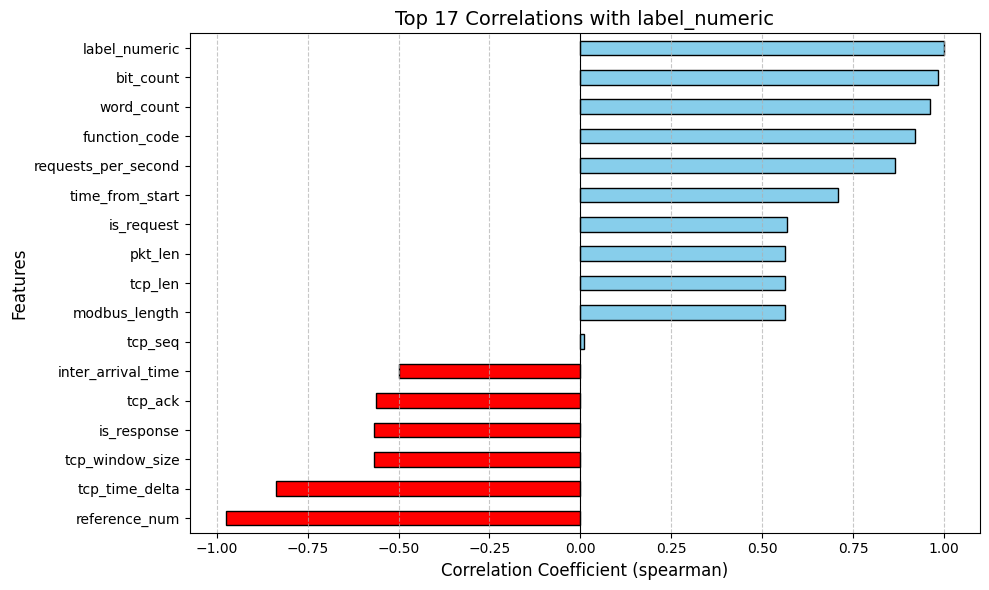

                     label_numeric
label_numeric             1.000000
bit_count                 0.981958
reference_num            -0.975464
word_count                0.960702
function_code             0.920057
requests_per_second       0.864216
tcp_time_delta           -0.836187
time_from_start           0.708941
is_request                0.568289
is_response              -0.568289
tcp_window_size          -0.568289
tcp_ack                  -0.562758
tcp_len                   0.561418
pkt_len                   0.561418
modbus_length             0.561415
inter_arrival_time       -0.498524
tcp_seq                   0.010707
label_numeric          1.000000
bit_count              0.981825
word_count             0.960532
function_code          0.844201
requests_per_second    0.723761
time_from_start        0.578850
is_request             0.568289
tcp_len                0.544962
pkt_len                0.544962
modbus_length          0.544960
tcp_seq                0.010706
FIN               

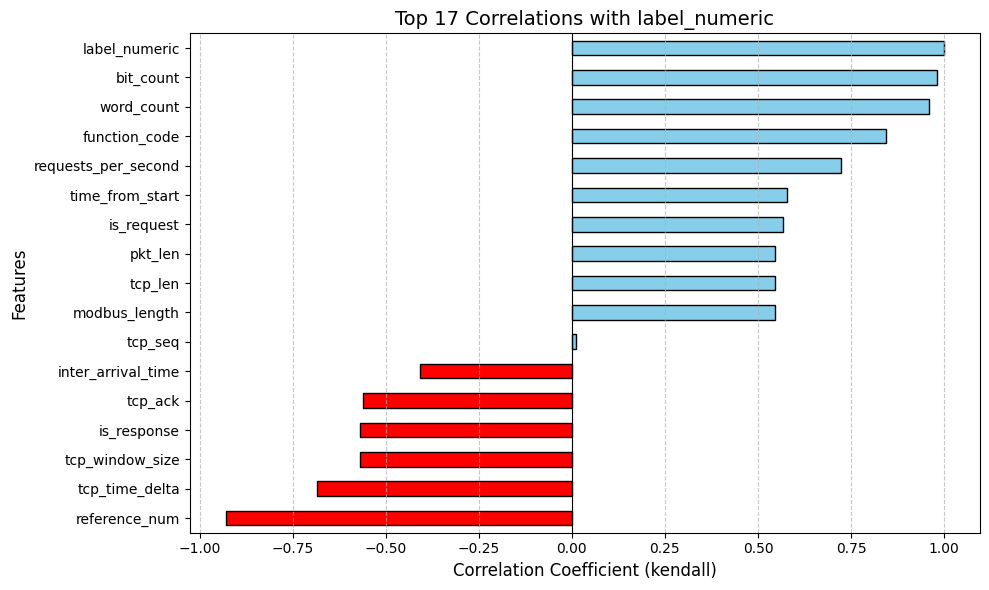

                     label_numeric
label_numeric             1.000000
bit_count                 0.981825
word_count                0.960532
reference_num            -0.930293
function_code             0.844201
requests_per_second       0.723761
tcp_time_delta           -0.685444
time_from_start           0.578850
is_request                0.568289
is_response              -0.568289
tcp_window_size          -0.568289
tcp_ack                  -0.561955
tcp_len                   0.544962
pkt_len                   0.544962
modbus_length             0.544960
inter_arrival_time       -0.407126
tcp_seq                   0.010706


In [ ]:
# Create numeric label FIRST
attack_data['label_numeric'] = (attack_data['label'] == 'ANOMALY').astype(int)
benign_data['label_numeric'] = (benign_data['label'] == 'ANOMALY').astype(int)

# Then drop columns
columns_to_drop = [
    'packet_number',
    'timestamp',
    'datetime',
    'src_ip',
    'dst_ip',
    'src_port',
    'dst_port',
    'tcp_stream',
    'transaction_id',
    'protocols',
    'unit_id',
    'tcp_flags',
    'function_name',
    'label',              # Drop original label after creating numeric version
    'request_frame',
    'response_frame',
]

attack_data = attack_data.drop(columns=columns_to_drop, errors='ignore')

# Compare all three
for method in ['pearson', 'spearman', 'kendall']:
    target_variable = 'label_numeric'

    # Calculate correlations 
    correlations = attack_data.corr(method=method)[target_variable].sort_values(ascending=False)
    print(correlations)

    # Get top features by absolute value
    number_of_features = 17
    top_feature_names = correlations.abs().sort_values(ascending=False).head(number_of_features).index

    # Get actual correlation values (not absolute)
    top_correlations = correlations[top_feature_names].sort_values(ascending=True)

    # Plot with color coding
    plt.figure(figsize=(10, 6))
    colors = ['red' if x < 0 else 'skyblue' for x in top_correlations]
    top_correlations.plot(kind='barh', color=colors, edgecolor='black')
    plt.title(f'Top {number_of_features} Correlations with {target_variable}', fontsize=14)
    plt.xlabel(f'Correlation Coefficient ({method})', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)  # Add zero line
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Print with actual values
    print(correlations[top_feature_names].to_frame())

In [71]:
target_variable = 'label_numeric'
method = 'pearson'  # You can change this to 'spearman' or 'kendall' as needed

# Calculate correlations 
correlations = attack_data.corr(method=method)[target_variable].sort_values(ascending=False)

# Get top features by absolute value
number_of_features = 17
top_feature_names = correlations.abs().sort_values(ascending=False).head(number_of_features).index

print(list(top_feature_names))

['label_numeric', 'reference_num', 'function_code', 'requests_per_second', 'time_from_start', 'is_request', 'is_response', 'tcp_window_size', 'tcp_ack', 'modbus_length', 'tcp_len', 'pkt_len', 'word_count', 'bit_count', 'inter_arrival_time', 'tcp_time_delta', 'tcp_seq']


In [72]:
print(attack_data.columns.tolist())

['tcp_len', 'tcp_time_delta', 'tcp_seq', 'tcp_ack', 'tcp_window_size', 'tcp_retransmission', 'tcp_duplicate_ack', 'tcp_lost_segment', 'tcp_out_of_order', 'protocol_id', 'modbus_length', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'response_time', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'FIN', 'SYN', 'RST', 'PSH', 'ACK', 'URG', 'inter_arrival_time', 'time_from_start', 'requests_per_second', 'round_trip_time', 'label_numeric']


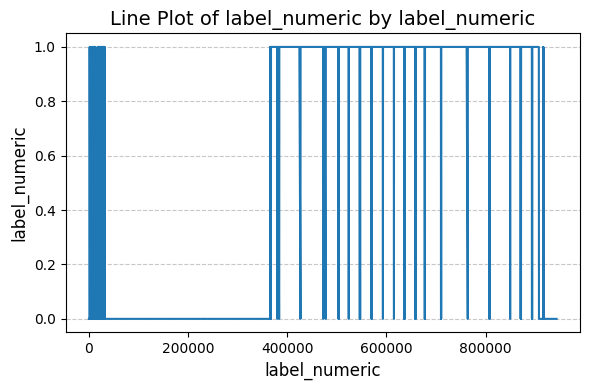

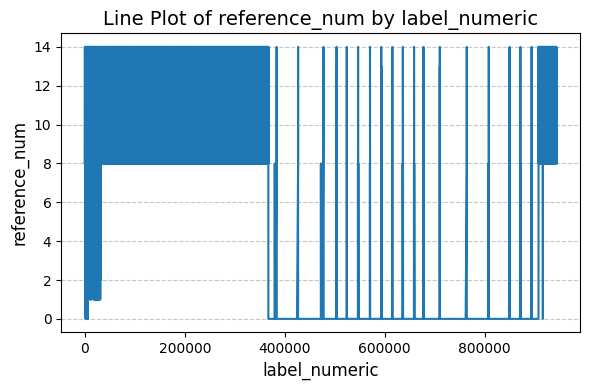

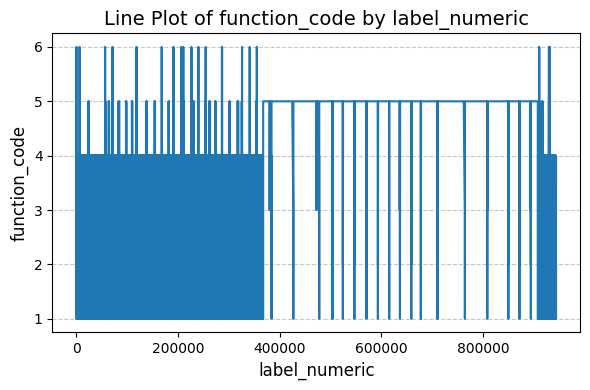

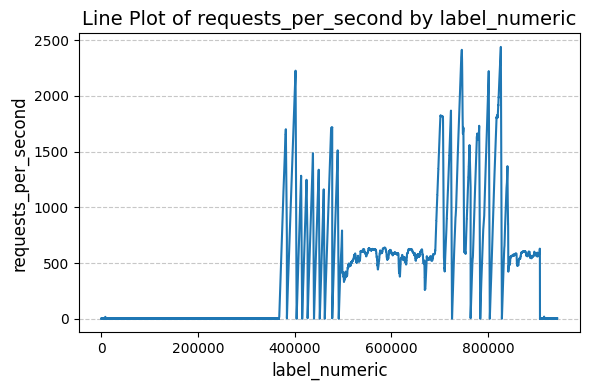

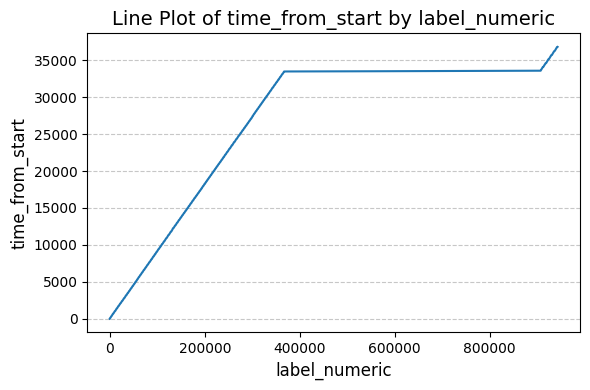

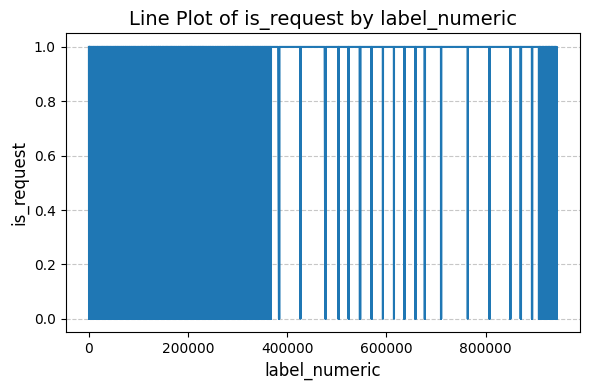

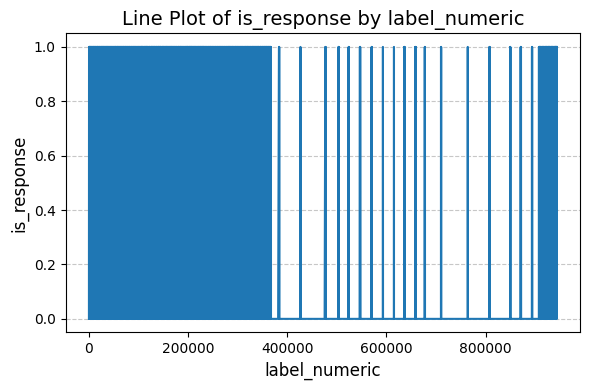

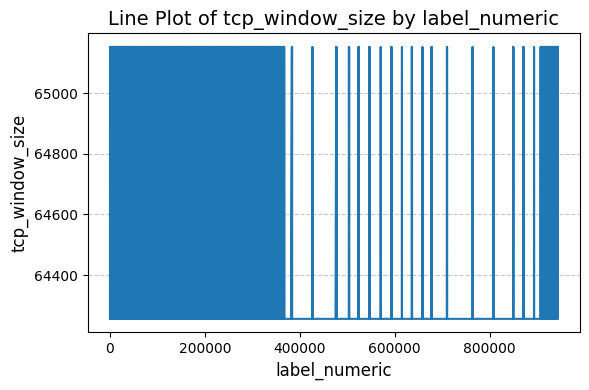

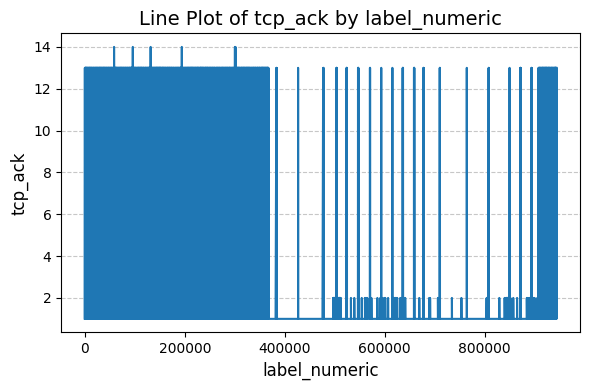

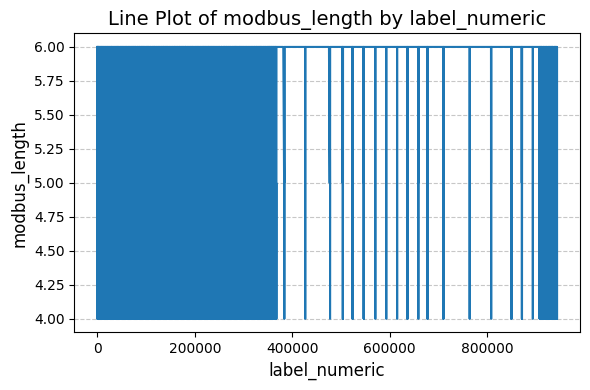

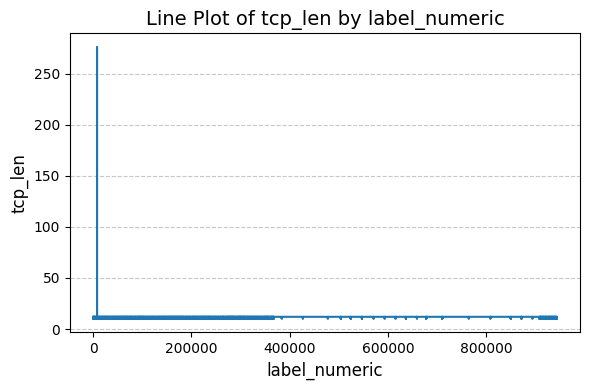

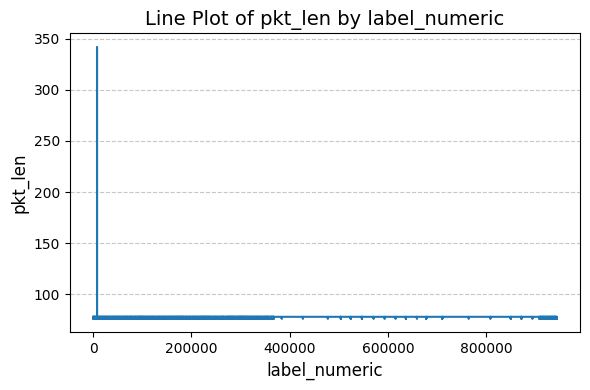

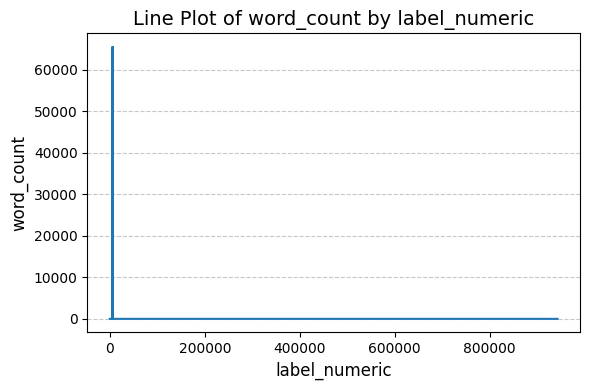

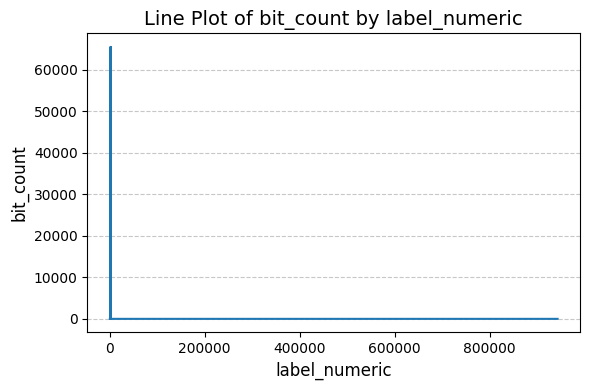

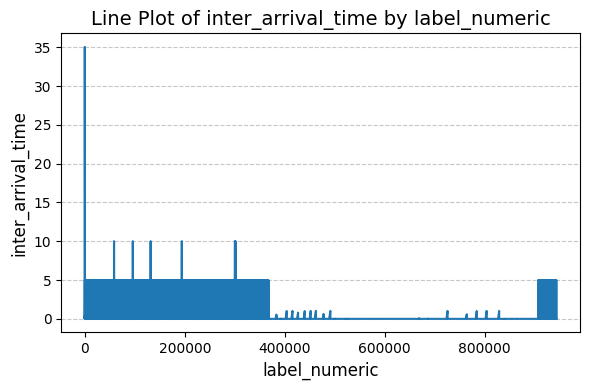

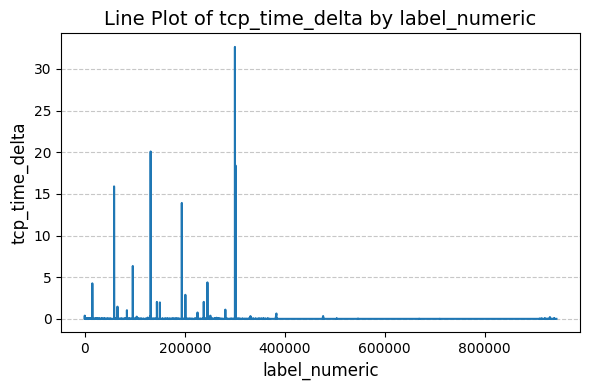

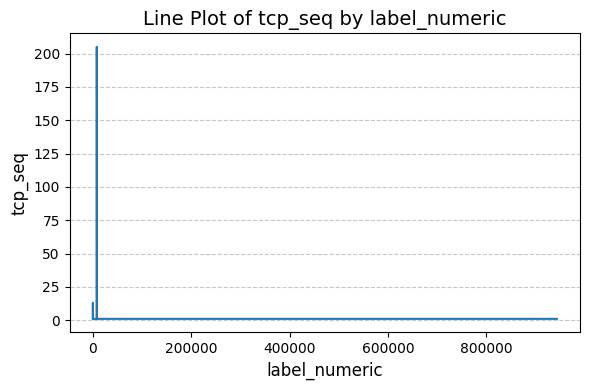

In [76]:
# Plot line plots for top features in attack data
for feature in top_feature_names:
    plt.figure(figsize=(6, 4))
    sns.lineplot(x=attack_data_copy["packet_number"], y=attack_data[feature]) # Put copy in x-axis to preserve original packet numbers for plotting
    plt.title(f'Line Plot of {feature} by {target_variable}', fontsize=14)
    plt.xlabel(target_variable, fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()